In [1]:
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
X_test = pd.read_csv("../datasets/X_test.csv")

y_test = pd.read_csv("../datasets/y_test.csv").squeeze()

print(X_test.shape)
print(y_test.shape)

(21, 10)
(21,)


In [3]:
model = joblib.load("../models/flood_model.pkl")

print(model)

RandomForestClassifier(random_state=42)


In [4]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [5]:
accuracy = accuracy_score(y_test,y_pred)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.9524


In [6]:
precision = precision_score(y_test,y_pred)

print(f"Precision : {precision:.4f}")

Precision : 1.0000


In [7]:
recall = recall_score(y_test,y_pred)

print(f"Recall : {recall:.4f}")

Recall : 0.5000


In [8]:
f1 = f1_score(y_test,y_pred)

print(f"F1 Score : {f1:.4f}")

F1 Score : 0.6667


In [9]:
roc = roc_auc_score(y_test,y_prob)

print(f"ROC AUC : {roc:.4f}")

ROC AUC : 0.9737


In [10]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00      0.50      0.67         2

    accuracy                           0.95        21
   macro avg       0.97      0.75      0.82        21
weighted avg       0.95      0.95      0.95        21



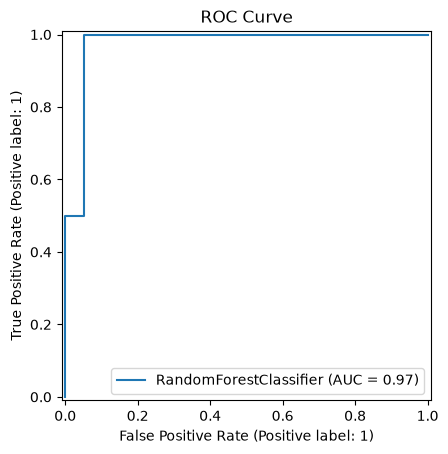

In [12]:
RocCurveDisplay.from_estimator(
    model,
    X_test,
    y_test
)

plt.title("ROC Curve")

plt.show()

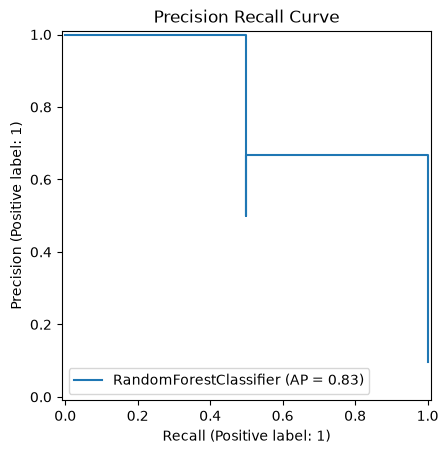

In [13]:
PrecisionRecallDisplay.from_estimator(
    model,
    X_test,
    y_test
)

plt.title("Precision Recall Curve")

plt.show()

In [14]:
importance = pd.DataFrame({

    "Feature":X_test.columns,

    "Importance":model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
6,Jun-Sep,0.488649
3,ANNUAL,0.245307
9,sub,0.116494
8,avgjune,0.043184
2,Cloud Cover,0.036374
7,Oct-Dec,0.024167
4,Jan-Feb,0.020554
5,Mar-May,0.015151
0,Temp,0.007027
1,Humidity,0.003094


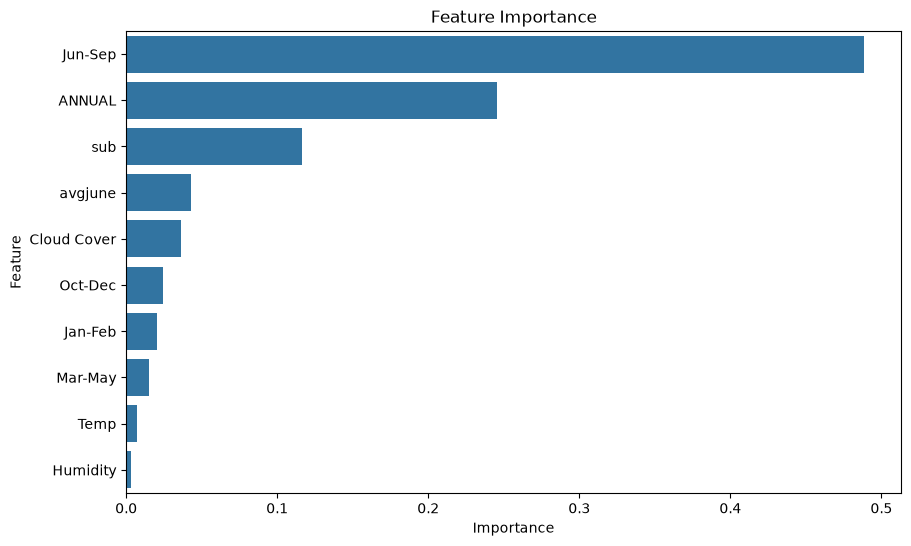

In [15]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

In [16]:
importance.to_csv(
    "../models/feature_importance.csv",
    index=False
)

print("Feature Importance Saved")

Feature Importance Saved


In [17]:
metrics = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Score":[
        accuracy,
        precision,
        recall,
        f1,
        roc
    ]

})

metrics

,Metric,Score
0,Accuracy,0.952381
1,Precision,1.000000
2,Recall,0.500000
3,F1 Score,0.666667
4,ROC AUC,0.973684


In [18]:
metrics.to_csv(
    "../models/evaluation_metrics.csv",
    index=False
)

print("Metrics Saved Successfully")

Metrics Saved Successfully


In [19]:
print("="*60)

print("MODEL EVALUATION COMPLETED")

print("="*60)

print(metrics)

print()

print("Best Model : Random Forest")

MODEL EVALUATION COMPLETED
      Metric     Score
0   Accuracy  0.952381
1  Precision  1.000000
2     Recall  0.500000
3   F1 Score  0.666667
4    ROC AUC  0.973684

Best Model : Random Forest
